# A4 — Cross-decoding: is the shared electrode carrying a shared *code*?

*Tutorial for `src/analysis/decoding/cross_decoding.py` (plan §4).*

**Why counting isn't enough.** A1/A2 can show the *same electrodes* are selective
for both stability (LWPC) and flexibility (LWPS). But an electrode being "both"
can mean two very different things:

- **Shared code** — one representational geometry that both processes ride on
  (the same population axis separates congruent/incongruent *and*
  switch/repeat), or
- **Orthogonal codes** — the electrode multiplexes two *independent* codes that
  happen to co-locate.

Counting cannot tell these apart. **Cross-decoding can**: train a classifier on
one contrast and test it on the other. If the decision axis transfers, the code
is shared; if each contrast is decodable but the axis does *not* transfer, the
codes are orthogonal (segregation at the representational level).

This notebook walks the module's building blocks and its four designs, and — the
whole point — shows on ground-truth synthetic data that cross-decoding
**discriminates a shared code from orthogonal codes**.

**The confound controls are baked in** (plan §0.8): disjoint train/test
pseudo-trials (circularity guard), trial-count matching, per-condition mean
removal (univariate-offset control), and a label-permutation null.

In [1]:
import os, sys
here = os.getcwd(); root = here
for _ in range(6):
    if os.path.exists(os.path.join(root, 'src', 'analysis')):
        break
    root = os.path.dirname(root)
if root not in sys.path:
    sys.path.insert(0, root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis.decoding import cross_decoding as cd
print("loaded cross_decoding from", cd.__file__)
print("classifier backend:", "project Decoder" if cd._DECODER_AVAILABLE else
      "sklearn fallback (ieeg not importable here)")

loaded cross_decoding from /home/user/GlobalLocal/src/analysis/decoding/cross_decoding.py
classifier backend: sklearn fallback (ieeg not importable here)


## 🧩 How this analysis question became code modules

Watch the deconstruction before the details. A4 starts from a limitation of the
*previous* assignments and turns it into a pipeline.

> **Design problem.** *"A1/A2 showed the same electrodes are selective for both
> stability and flexibility. Is that one **shared code**, or two **orthogonal
> codes** that merely co-locate? Counting can't tell them apart — build something
> that can."*

The move that unlocks the code: pick a **discriminating operation** whose result
differs between the two hypotheses, then list what that operation needs.

- The discriminating operation is *transfer*: **train a classifier on one contrast,
  test it on the other.** Shared code → the decision axis transfers; orthogonal
  codes → each is decodable but the axis does **not** transfer. → `cross_decode`.
- Transfer needs *examples*, but subjects don't share trials → pool electrodes into a
  **pseudopopulation** and synthesise **pseudo-trials**. → `assemble_pseudopopulation`,
  `build_pseudo_trials`.
- Any decode invites *four confounds*; each becomes its own small mechanism:

| Confound (the trap) | Code that defends against it |
|---|---|
| circularity (same trial in train & test) | `_split_reservoirs` → disjoint reservoirs *before* pseudo-trials |
| unequal trial counts drive "decodability" | fixed `n_per_cell` / `n_pseudo` per cell |
| a univariate offset masquerades as a code | `strip_condition_means=True` |
| "above chance" needs a chance estimate | label-permutation null (the `p` on every result) |

Then the *designs* are just this core pointed at different questions: a within-block
baseline (`within_block_decoding_baseline`, Fig 9), label-transfer (the headline),
temporal generalisation (`temporal_generalization`, Fig 10), and set comparison
(`mode='set_transfer'`).

The lesson to internalise: **"counting can't distinguish X from Y" → find the one
operation whose output separates X from Y → enumerate that operation's confounds →
one function per confound.** That chain is the whole module.

## 0. The data model and the pseudopopulation

A4 runs on the **same** long-format single-trial table as A1–A3, assembled with
`effect_measure='cluster'` so each row's `hg` is that trial's HG **time course**:

```
subject | electrode | congruency (c/i) | switchType (s/r)
        | incongruent_proportion | switch_proportion | hg = ndarray(n_time)
```

Subjects don't share trials, so we pool electrodes into a **pseudopopulation** and
build **pseudo-trials** by matching on the full condition cell
(congruency × inc_prop × switchType × switch_prop). We validate on
`_synthetic_cross_df`, which plants a *known* code:

- `code='shared'` → congruency and switchType load on the **same** population
  axis → a decoder trained on one should transfer to the other.
- `code='orthogonal'` → they load on **orthogonal** axes → each is decodable, but
  training on one should **not** transfer to the other.

In [2]:
df_shared = cd._synthetic_cross_df(code='shared', seed=1)
df_orth   = cd._synthetic_cross_df(code='orthogonal', seed=1)
print("shared df:", df_shared.shape, "| electrodes:", df_shared.electrode.nunique(),
      "| subjects:", df_shared.subject.nunique())
df_shared.head(3)

shared df: (7390, 7) | electrodes: 40 | subjects: 4


,subject,electrode,congruency,switchType,incongruent_proportion,switch_proportion,hg
0,S00,S00-e0,c,r,25.0,75.0,"[-1.1036092659277856, -1.1278871762586364, -0...."
1,S00,S00-e0,i,r,75.0,25.0,"[-0.7823985759494164, -0.18424200221796436, 0...."
2,S00,S00-e0,i,r,25.0,25.0,"[0.43418114048221673, -0.8848818751587286, -0...."


**🧠 Quiz**

A1/A2 established that the *same electrodes* are selective for both stability and flexibility. Why can that finding **not** distinguish a shared neural code from two independent codes?

<details>
<summary>👉 Click to reveal the answer</summary>

Because an electrode being 'both'-selective is consistent with two very different realities: (i) a single population axis that separates congruent/incongruent *and* switch/repeat — one **shared code**; or (ii) the electrode multiplexing two **orthogonal** codes that happen to sit on the same contacts. Counting how many electrodes are 'both' cannot see the *geometry* — both realities produce the same count. You need an operation that reads the representational axes, and that is what cross-decoding (transfer) does.

</details>

### Pseudo-trials from disjoint reservoirs (the circularity guard)

`assemble_pseudopopulation` indexes the df into `{electrode: {cell: trials×time}}`.
`_split_reservoirs` then splits *each electrode's trials, within each cell,* into
disjoint train/test halves **before any pseudo-trial is drawn** — so a trial that
helps build a train pseudo-trial can never reappear in a test pseudo-trial.
`build_pseudo_trials` averages `n_per_cell` trials per electrode per draw and
stacks electrodes into a `(n_channel, n_time)` pseudo-trial.

In [3]:
pop, channels, n_time, cc = cd.assemble_pseudopopulation(df_shared)
rng = np.random.default_rng(0)
res = cd._split_reservoirs(pop, rng)
Xtr, ytr, ctr = cd.build_pseudo_trials(pop, channels, n_time, cc, 'congruency',
                                       res, side=0, n_per_cell=5, n_pseudo=40, rng=rng)
Xte, yte, cte = cd.build_pseudo_trials(pop, channels, n_time, cc, 'congruency',
                                       res, side=1, n_per_cell=5, n_pseudo=40, rng=rng)
print("train pseudo-trials:", Xtr.shape, "(n_pseudo, n_channel, n_time)")
print("test  pseudo-trials:", Xte.shape)
print("class balance (train):", dict(zip(*np.unique(ytr, return_counts=True))))

train pseudo-trials: (640, 40, 16) (n_pseudo, n_channel, n_time)
test  pseudo-trials: (640, 40, 16)
class balance (train): {np.int64(0): np.int64(320), np.int64(1): np.int64(320)}


**🧠 Quiz**

`_split_reservoirs` splits each electrode's trials, **within each condition cell**, into disjoint train/test halves *before* a single pseudo-trial is averaged. Suppose you instead built all the pseudo-trials first and split them into train/test afterwards. What exactly leaks, and why does it inflate transfer accuracy?

<details>
<summary>👉 Click to reveal the answer</summary>

A single **real** trial would then be free to contribute to a *train* pseudo-trial and also to a *test* pseudo-trial (each pseudo-trial averages several real trials drawn from the same pool). That's train/test leakage: the test set is no longer independent of what the classifier saw, so accuracy is inflated toward whatever the shared trials encode — the same double-dipping bug as in the trial-splitting tutorial, one level up. Splitting the *reservoirs first* makes it structurally impossible for a real trial to appear on both sides.

</details>

## Design 0 (Fig 9) — within-block decoding baseline

Before any transfer, decode a contrast *within each block type* and compare. E.g.
decode congruency (inc vs con) within the mostly-congruent vs mostly-incongruent
blocks. This is the decoding analog of the univariate LWPC/LWPS effects; a block
difference in decodability is a **neural cross-effect**. Trial counts are matched
across blocks by construction (fixed `n_per_cell`/`n_pseudo` per cell), and chance
is estimated by a label-permutation null.

In [4]:
wb = cd.within_block_decoding_baseline(df_shared, contrast='congruency',
                                       n_pseudo=60, n_folds=3, n_perm=200,
                                       rng=np.random.default_rng(0))
for b in wb['blocks']:
    r = wb['per_block'][b]
    print(f"  incongruent_proportion={b}: acc={r['accuracy']:.3f}  (null~{r['null_mean']:.3f}, p={r['p']:.3f})")
print(f"  block difference (high - low): {wb['block_difference']:+.3f}")

  incongruent_proportion=25.0: acc=0.790  (null~0.498, p=0.005)
  incongruent_proportion=75.0: acc=0.795  (null~0.501, p=0.005)
  block difference (high - low): +0.005


## Designs (a)/(c) — the shared-vs-orthogonal test

### (a) label transfer: train stability, test flexibility

`cross_decode(df, 'stability', 'flexibility', ...)` trains on the congruency
contrast and tests whether that decision axis separates the switch contrast — on
**disjoint** pseudo-trials. We run it on both the shared and the orthogonal
synthetic, each time also reporting:
- an individually-decodable sanity check (train & test the *same* contrast), and
- the **per-condition-mean-removed** version (`strip_condition_means=True`): if
  the transfer rides on a univariate offset, removing each condition's per-feature
  mean collapses it to chance.

In [5]:
def report(df, tag):
    rng = np.random.default_rng(0)
    within = cd.cross_decode(df, 'congruency', 'congruency', n_pseudo=60, n_folds=3, n_perm=300, rng=rng)
    cross  = cd.cross_decode(df, 'stability', 'flexibility', n_pseudo=60, n_folds=3, n_perm=300, rng=rng)
    crossmr= cd.cross_decode(df, 'stability', 'flexibility', strip_condition_means=True,
                             n_pseudo=60, n_folds=3, n_perm=300, rng=rng)
    print(f"[{tag}]")
    print(f"    within congruency (decodable?):   acc={within['accuracy']:.3f}  p={within['p']:.3f}")
    print(f"    cross stability->flexibility:      acc={cross['accuracy']:.3f}  p={cross['p']:.3f}")
    print(f"    cross, per-condition-mean-removed: acc={crossmr['accuracy']:.3f}  p={crossmr['p']:.3f}")
    return within, cross, crossmr

sh = report(df_shared, 'SHARED code')
print()
orth = report(df_orth, 'ORTHOGONAL code')

[SHARED code]
    within congruency (decodable?):   acc=0.784  p=0.003
    cross stability->flexibility:      acc=0.686  p=0.003
    cross, per-condition-mean-removed: acc=0.495  p=0.757



[ORTHOGONAL code]
    within congruency (decodable?):   acc=0.956  p=0.003
    cross stability->flexibility:      acc=0.472  p=0.060
    cross, per-condition-mean-removed: acc=0.501  p=0.914


**Read the result.**

- **Shared code:** congruency is decodable *and* the axis transfers to flexibility
  (cross acc > chance, small p). The shared geometry is real.
- **Orthogonal code:** congruency is *just as decodable*, but the axis does **not**
  transfer (cross acc ≈ 0.5, p n.s.). Two independent codes on the same electrodes.

This is exactly the discrimination counting analyses cannot make.

**About the mean-removed column.** In this synthetic the shared signal is a
*rank-1 mean shift* along the shared axis, so removing each condition's per-feature
mean removes the very thing being decoded and the transfer drops to chance. That
is the univariate-offset control **working**: it tells you *this* shared transfer
was carried by a mean offset. On real data you report both numbers — a transfer
that **survives** mean removal is the bar for claiming a genuine *multivariate*
shared code; one that doesn't is "just" a shared univariate offset. Either way the
raw-vs-removed pair is the honest thing to report.

**🧠 Quiz**

On the **orthogonal** synthetic, within-congruency decoding is ~0.96 (extremely decodable) yet `stability→flexibility` cross-decoding is ~0.47 (chance). How can a signal be *highly decodable* and *not transfer at all* at the same time?

<details>
<summary>👉 Click to reveal the answer</summary>

Because 'decodable' and 'shared' are different questions. Each contrast is decodable **on its own axis** — congruency lives on axis *u*, switch on an orthogonal axis *v*, and each is easy to read when you train and test on the same one. But the LDA decision boundary learned for congruency points along *u*, which is orthogonal to *v*, so it carries **zero** information about switch → transfer collapses to chance. High within-contrast accuracy tells you the code *exists*; only transfer tells you whether it's the *same* code.

</details>

**🧠 Quiz**

On the **shared** synthetic, transfer drops from 0.686 (raw) to 0.495 (`strip_condition_means=True`). Does that collapse mean the shared code was an artifact you should discard?

<details>
<summary>👉 Click to reveal the answer</summary>

No — it means *this particular* shared transfer was carried by a **univariate mean offset**, and the control correctly detected that. In this synthetic the shared signal is a rank-1 mean shift along the shared axis, so removing each condition's per-feature mean removes exactly the decoded quantity. That's the control *working*, not failing. The honest report is the **pair** of numbers: a transfer that *survives* mean removal is the bar for a genuine **multivariate** shared code; one that doesn't is 'just' a shared univariate offset — still a real, reportable fact, just a weaker claim. You never report only one of the two.

</details>

**✍️ Assignment**

Transfer should be roughly **symmetric** for a truly shared code. Run `cd.cross_decode` both directions on `df_shared` — `stability→flexibility` and `flexibility→stability` — and compare the two accuracies. Then run the same both-directions test on `df_orth` and confirm neither direction transfers.

In [ ]:
# ✍️ your turn:


<details><summary>👉 Solution</summary>

```python
import numpy as np
for tag, df in [("SHARED", df_shared), ("ORTHOGONAL", df_orth)]:
    s2f = cd.cross_decode(df, 'stability', 'flexibility',
                          n_pseudo=60, n_folds=3, n_perm=200, rng=np.random.default_rng(0))
    f2s = cd.cross_decode(df, 'flexibility', 'stability',
                          n_pseudo=60, n_folds=3, n_perm=200, rng=np.random.default_rng(0))
    print(f"[{tag}]  stab->flex={s2f['accuracy']:.3f} (p={s2f['p']:.3f})  "
          f"flex->stab={f2s['accuracy']:.3f} (p={f2s['p']:.3f})")
# SHARED: both directions above chance and similar (a shared axis is symmetric).
# ORTHOGONAL: both ~0.5, n.s. — no axis to transfer, either way.
```

Symmetry is a sanity check, not a proof: a shared *linear* axis transfers both ways by construction. A large asymmetry on real data is a flag that the two contrasts aren't riding the same simple axis.
</details>

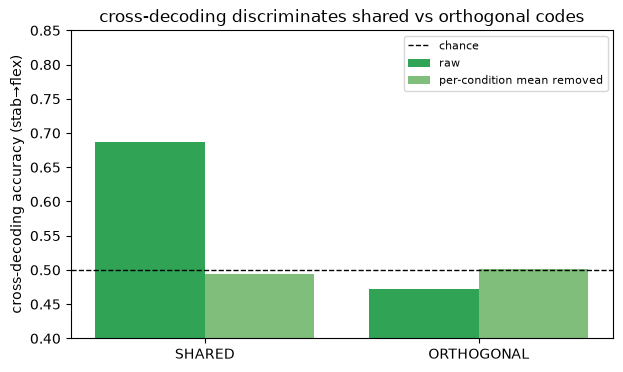

In [6]:
# bar chart: cross-decoding accuracy, shared vs orthogonal, raw vs mean-removed
labels = ['SHARED', 'ORTHOGONAL']
raw = [sh[1]['accuracy'], orth[1]['accuracy']]
mr  = [sh[2]['accuracy'], orth[2]['accuracy']]
x = np.arange(2)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x-0.2, raw, 0.4, label='raw', color="#31a354")
ax.bar(x+0.2, mr, 0.4, label='per-condition mean removed', color="#7fbf7b")
ax.axhline(0.5, ls='--', c='k', lw=1, label='chance')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set(ylabel='cross-decoding accuracy (stab→flex)', ylim=(0.4, 0.85),
       title='cross-decoding discriminates shared vs orthogonal codes')
ax.legend(fontsize=8); plt.show()

### (c) temporal generalization (Fig 10)

`temporal_generalization` trains a classifier at each time bin `t` and tests it at
every time bin `t'`, giving a train×test accuracy matrix. Off-diagonal
generalization → a **sustained/stable** code; a narrow diagonal → a
**moving/phasic** code. Run within a contrast, or across contrasts for a
cross-temporal transfer. (Our synthetic injects the effect into the middle of the
window, so the on-effect block sits in the centre.)

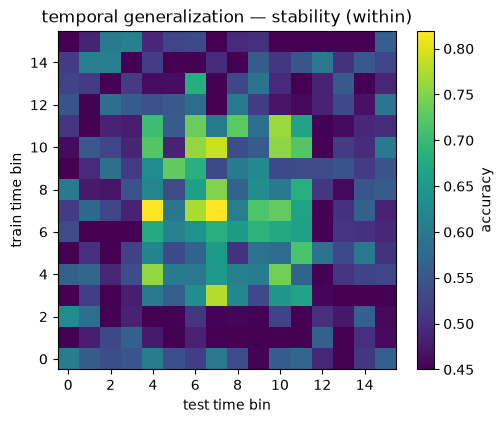

mean diagonal: 0.594


In [7]:
tg = cd.temporal_generalization(df_shared, 'stability', electrodes=None,
                                n_pseudo=40, n_folds=2, rng=np.random.default_rng(0))
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(tg['matrix'], origin='lower', cmap='viridis', vmin=0.45,
               vmax=max(0.6, tg['matrix'].max()))
ax.set(title="temporal generalization — stability (within)",
       xlabel="test time bin", ylabel="train time bin")
fig.colorbar(im, ax=ax, fraction=0.046, label='accuracy'); plt.show()
print("mean diagonal:", round(float(np.mean(np.diag(tg['matrix']))), 3))

### (b) set comparison

`cross_decode(..., mode='set_transfer', electrode_sets={...})` decodes the **same
label within each electrode set**, so you can compare where a code lives (e.g. the
A1 `both` vs `S_only` vs `F_only` groups). Note: true cross-*feature* transfer
across *non-corresponding* electrodes isn't identifiable — different channels are
different feature axes — so the module reports each set's same-label decodability
with its own null rather than pretending to port an LDA axis across disjoint
features. Design (a) label-transfer is the representation-overlap test.

In [8]:
elecs = sorted(df_shared.electrode.unique()); half = len(elecs)//2
sets = {'setA': elecs[:half], 'setB': elecs[half:]}
st = cd.cross_decode(df_shared, 'congruency', mode='set_transfer', electrode_sets=sets,
                     n_pseudo=50, n_folds=3, n_perm=200, rng=np.random.default_rng(0))
for name, r in st['per_set'].items():
    print(f"  {name}: congruency acc={r['accuracy']:.3f}  (p={r['p']:.3f}, n_channels={r['n_channels']})")

  setA: congruency acc=0.640  (p=0.005, n_channels=20)
  setB: congruency acc=0.840  (p=0.005, n_channels=20)


**🧠 Quiz**

`mode='set_transfer'` reports each electrode set's **own** same-label decodability, with its own null — it deliberately refuses to train an LDA axis on set A and apply it to set B. Why is porting a decision axis across two disjoint electrode sets not even *identifiable*?

<details>
<summary>👉 Click to reveal the answer</summary>

Because different electrodes are **different feature dimensions**. An LDA weight vector learned on set A's channels lives in set A's feature space; applied to set B's channels it's multiplying weights by unrelated features — the numbers compute, but they mean nothing, and there's no ground truth to say the axis 'transferred'. Cross-*feature* transfer across non-corresponding channels is unidentifiable, so the module doesn't fake it. (The identifiable representation-overlap test is Design (a) label-transfer, where train and test share the *same* features and only the *label* changes.)

</details>

## Running it on real data

The productionised job lives in `dcc_scripts/decoding/`:

```bash
cd dcc_scripts/decoding
# validate the discrimination in ~a minute (planted shared code):
DATA_SOURCE=synthetic SYNTHETIC_CODE=shared bash submit_stability_flexibility_cross_decoding_dcc.sh
# the null (orthogonal) code:
DATA_SOURCE=synthetic SYNTHETIC_CODE=orthogonal bash submit_stability_flexibility_cross_decoding_dcc.sh
# real run — set EPOCHS_ROOT_FILE in the submit script, then:
bash submit_stability_flexibility_cross_decoding_dcc.sh
```

On real data it assembles the cluster-mode HG table, derives the A1 `both`/
`S_only`/`F_only` electrode groups (`per_electrode_anova_labels`), and runs all
four designs — label transfer **per group** (the headline: only `both` should
cross-decode), raw and mean-removed — writing `cross_decoding.json`, the
`tempgen_*.npy` matrices, `cross_decoding_summary.png`, and `summary.txt`.

### Acceptance criteria (plan §4 / §0.8), and where they're met
- **Circularity guard** → disjoint train/test reservoirs in
  `_split_reservoirs` / `build_pseudo_trials`.
- **Trial-count matched** → fixed `n_per_cell`/`n_pseudo` per cell.
- **Survives per-condition mean removal** → `strip_condition_means`, reported raw
  and removed for every transfer.
- **Null centred at chance for a real decode** → the label-permutation null
  (verified above: within-contrast decode significant, orthogonal cross-decode
  n.s.).

## 🛠️ Coding principles & design decisions used to build this module

1. **Turn a limitation into a discriminating operation.** The module exists because
   *counting can't distinguish shared from orthogonal codes*. The whole design is
   organised around the one operation that can — train-on-one, test-on-the-other — and
   everything else is scaffolding for it.

2. **One confound → one mechanism, each independently testable.** Circularity →
   `_split_reservoirs`; trial-count imbalance → fixed per-cell counts; univariate
   offset → `strip_condition_means`; "above chance?" → a permutation null. Bundling
   these into one monolith would make it impossible to know *which* guard is doing the
   work; as separate, named pieces each can be verified alone.

3. **Report pairs, not verdicts, where a control changes the claim.** Transfer is
   reported raw **and** mean-removed, every time. The code returns both numbers and
   lets the reader see the effect of the control, instead of silently applying it and
   hiding what it did.

4. **Refuse the unidentifiable instead of faking it.** `set_transfer` won't port an LDA
   axis across non-corresponding features — a lesser design would compute a
   meaningless number and print it. Knowing what your method *cannot* claim is part of
   the method.

5. **Validate discrimination on planted ground truth.** `_synthetic_cross_df(code=
   'shared')` and `code='orthogonal'` build data where you already know the answer, so
   §b/§c *prove* the method separates the two before it's ever pointed at real data. A
   method that can't recover a planted answer has no business interpreting an unknown one.

6. **Graceful backend fallback.** The classifier uses the project `Decoder` when the
   `ieeg` stack is importable and a scikit-learn LDA otherwise (see the first cell's
   `_DECODER_AVAILABLE` print), so the tutorial runs off-cluster without changing the
   logic under test.

### 🏁 Capstone
On `df_shared` and `df_orth`, assemble the full A4 story yourself and predict each
number *before* running:
1. `within_block_decoding_baseline` — is there a block difference in decodability?
2. label-transfer `stability→flexibility`, **raw and mean-removed** — which survives on
   which synthetic?
3. `temporal_generalization` within `stability` — square (sustained) or diagonal
   (phasic), given the effect is injected mid-window?
Write your predictions in the cell below, then run the three functions and check.

In [ ]:
# 🏁 capstone — your predictions, then verify:
